In [130]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

In [131]:
internal_data_analysis_dir = os.path.dirname(os.path.abspath('Data_visualization.ipynb'))
root_dir = os.path.abspath(os.path.join(internal_data_analysis_dir, '..'))
internal_data_collection_dir = os.path.abspath(os.path.join(internal_data_analysis_dir, 'May_06'))
print(f'The directory of data analysis : {internal_data_analysis_dir}')
print(f'The root directory of this project : {root_dir}')
print(f'The directory of collected data : {internal_data_collection_dir}')

The directory of data analysis : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results
The root directory of this project : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control
The directory of collected data : c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06


In [132]:
MPC_Data_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'MPC_controller_data'))
PD_data_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'PD_controller_data'))
#step_data_file_dir = os.path.abspath(os.path.join(internal_data_collection_dir, 'New_New_New_Data_CSV'))

In [133]:
for file in os.listdir(MPC_Data_dir):
    print(os.path.join(MPC_Data_dir, file))  

c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\MPC_controller_data\data_may_06_mpc_1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\MPC_controller_data\data_may_06_mpc_2.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\MPC_controller_data\logged_data_May06_Mpc_1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\MPC_controller_data\logged_data_May06_Mpc_2.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\MPC_controller_data\logged_data_May06_Mpc_3.csv


In [134]:
for file in os.listdir(PD_data_dir):
    print(os.path.join(PD_data_dir, file)) 

c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_1.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_2.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_3.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_5.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_6.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Adaptive-Cruise-Control\Adaptive-Cruise-Control\9_Vehicle_Testing_Results\May_06\PD_controller_data\data_may_06_pdc_7.csv
c:\Users\home\Desktop\ACC\Auto-Cruise\Ad

In [135]:
# Load data from the CSV files in the specified directories
mpc_data_files = [os.path.join(MPC_Data_dir, file) for file in os.listdir(MPC_Data_dir) if file.endswith('.csv')]
pd_data_files = [os.path.join(PD_data_dir, file) for file in os.listdir(PD_data_dir) if file.endswith('.csv')]

# Load the data into dataframes
mpc_dataframes = [pd.read_csv(file) for file in mpc_data_files]
pd_dataframes = [pd.read_csv(file) for file in pd_data_files]

# Print the number of files loaded
print(f"Loaded {len(mpc_dataframes)} MPC data files.")
print(f"Loaded {len(pd_dataframes)} PD data files.")

Loaded 5 MPC data files.
Loaded 13 PD data files.


In [136]:
# Display the first few rows of each MPC dataframe
print("MPC Dataframes:")
for i, df in enumerate(mpc_dataframes):
    print(f"\nMPC Dataframe {i+1}:")
    print(df.head())



MPC Dataframes:

MPC Dataframe 1:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000024
1              0.0                0.0  2.775009
2              0.0                0.0  2.886936
3              0.0                0.0  2.999604
4              0.0                0.0  3.110560

MPC Dataframe 2:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000014
1              0.0                0.0  4.726640
2              0.0                0.0  5.039071
3              0.0                0.0  5.349285
4              0.0                0.0  5.662280

MPC Dataframe 3:
   Log Timestamp  Distance (m)  Remaining Distance (m)  Velocity (m/s)  \
0   1.746513e+09           0.0                   100.0             0.0   
1   1.746513e+09           0.0                   100.0             0.0   
2   1.746513e+09           0.0                   100.0             0.0   
3   1.746513e+09           0.0                   100.0    

In [137]:
# Display the first few rows of each PD dataframe
print("\nPD Dataframes:")
for i, df in enumerate(pd_dataframes):
    print(f"\nPD Dataframe {i+1}:")
    print(df.head())


PD Dataframes:

PD Dataframe 1:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000006
1              0.0                0.0  4.189200
2              0.0                0.0  4.301194
3              0.0                0.0  4.413325
4              0.0                0.0  4.525403

PD Dataframe 2:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000023
1              0.0                0.0  4.262083
2              0.0                0.0  4.371534
3              0.0                0.0  4.482015
4              0.0                0.0  4.592304

PD Dataframe 3:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0              0.0                0.0  0.000021
1              0.0                0.0  5.986360
2              0.0                0.0  6.096137
3              0.0                0.0  6.205744
4              0.0                0.0  6.315674

PD Dataframe 4:
   Ego_Position(m)  Ego_Velocity(m/s)   Time(s)
0   

In [138]:
# Function to clean data by removing rows with invalid Remaining Distance or Ego Position values
def cleaning_data(df):
    # Check if the required columns exist and filter rows
    if "Remaining Distance (m)" in df.columns:
        df = df[(df["Remaining Distance (m)"] >= 0) & (df["Remaining Distance (m)"] <= 110)]
    if "Ego_Position(m)" in df.columns:
        df = df[(df["Ego_Position(m)"] >= 0) & (df["Ego_Position(m)"] <= 110)]
    return df

# Apply the cleaning function to all MPC and PD dataframes
mpc_dataframes = [cleaning_data(df) for df in mpc_dataframes]
pd_dataframes = [cleaning_data(df) for df in pd_dataframes]

print("Data cleaned. Rows with Remaining Distance (m) or Ego_Position(m) > 110 or < 0 have been removed.")

Data cleaned. Rows with Remaining Distance (m) or Ego_Position(m) > 110 or < 0 have been removed.



MPC Dataframe 1 - Plotting Distance and Velocity:
These dataframes are autologged during testing 1


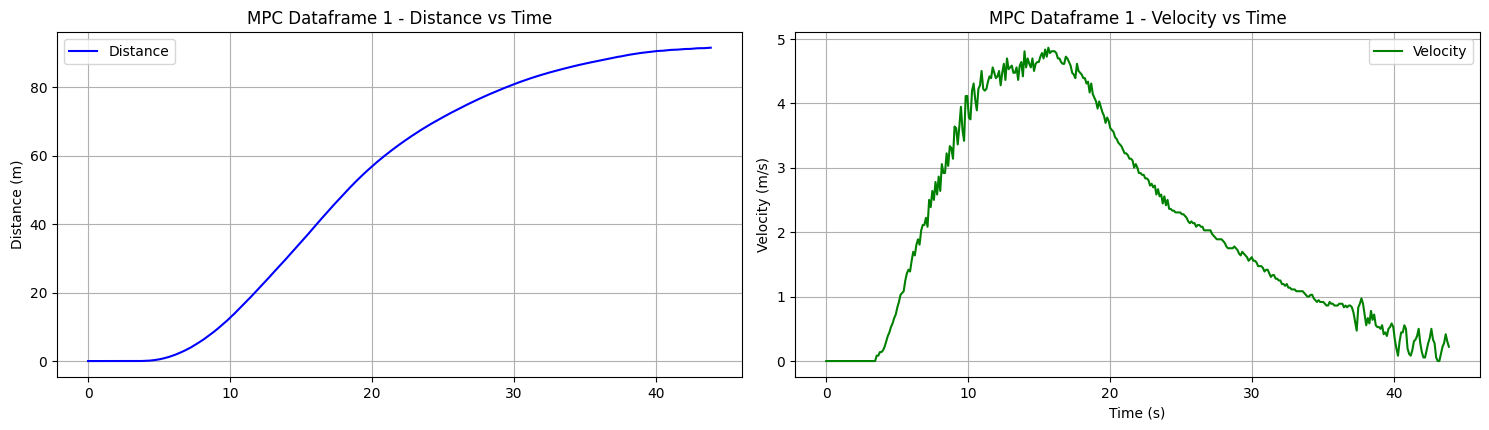


MPC Dataframe 2 - Plotting Distance and Velocity:
These dataframes are autologged during testing 2


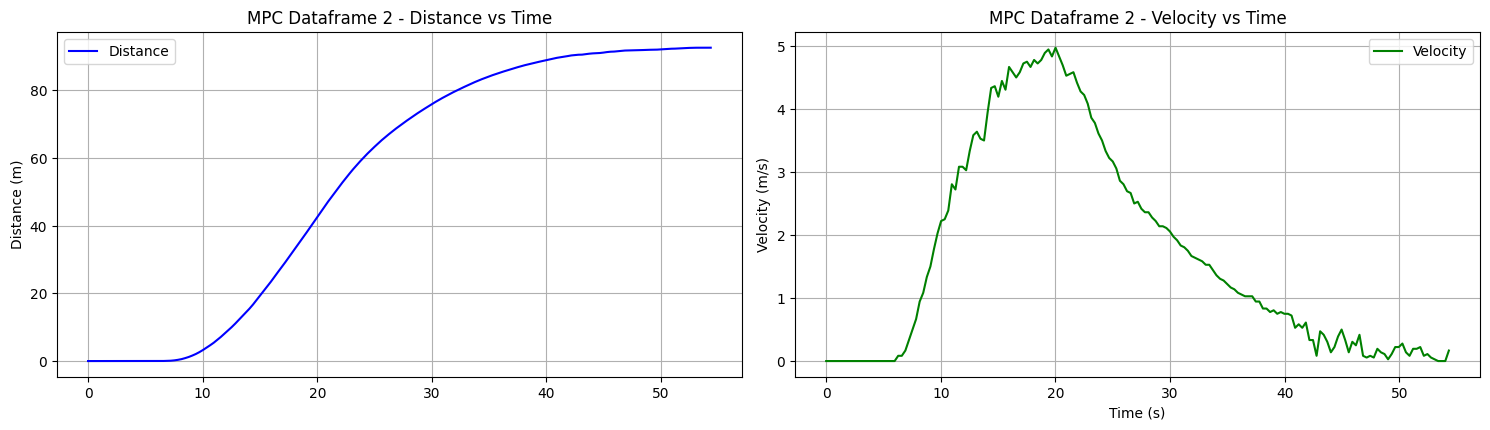


MPC Dataframe 3 - Plotting Distance and Velocity:


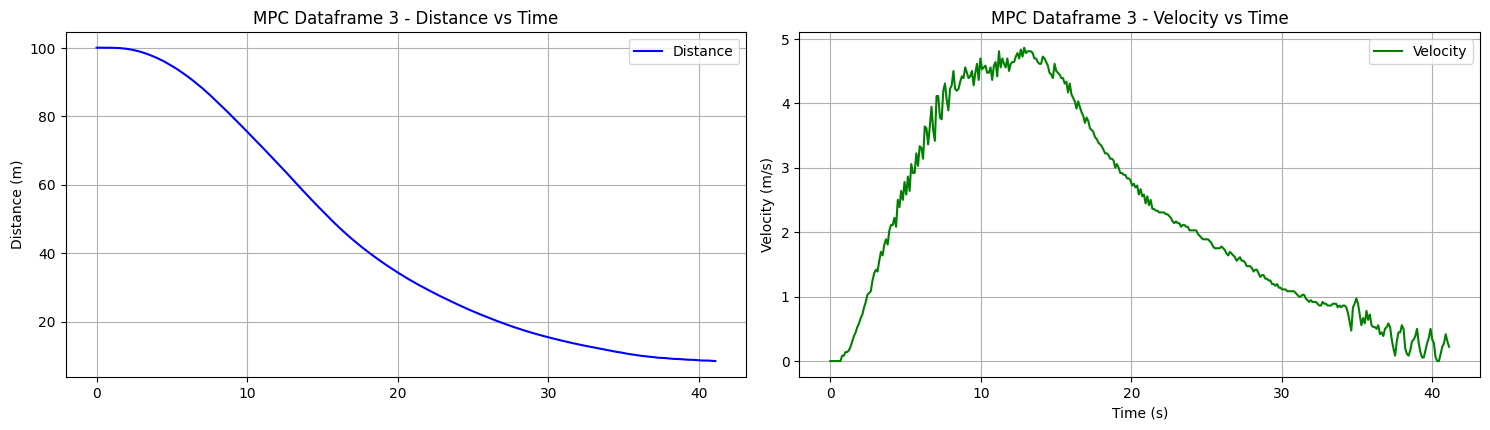


MPC Dataframe 4 - Plotting Distance and Velocity:


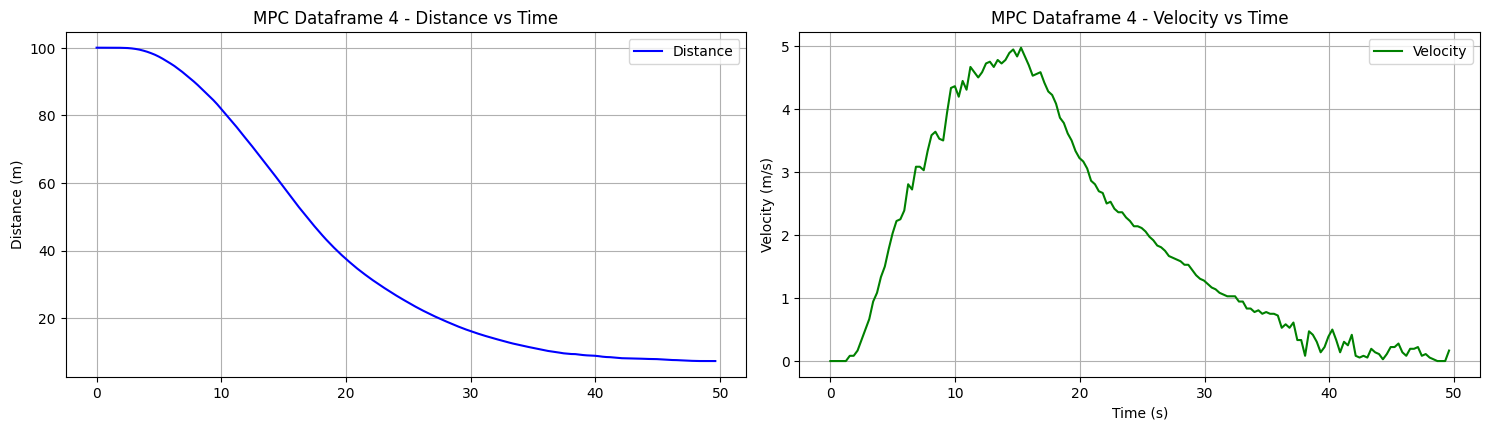


MPC Dataframe 5 - Plotting Distance and Velocity:


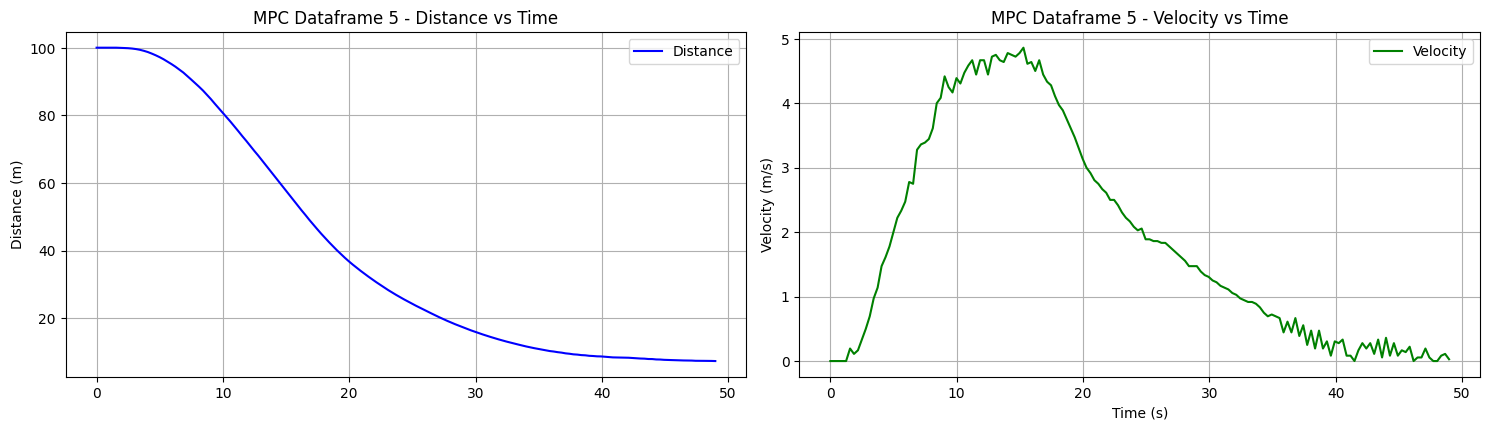

In [139]:

# Plot Distance vs Time and Velocity vs Time for each dataframe
for i, df in enumerate(mpc_dataframes):
    print(f"\nMPC Dataframe {i+1} - Plotting Distance and Velocity:")
    
    # Check if the required columns exist
    if "Time (s)" in df.columns and "Remaining Distance (m)" in df.columns and "Velocity (m/s)" in df.columns:
        plt.figure(figsize=(15, 8))

        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time (s)"], df["Remaining Distance (m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"MPC Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time (s)"], df["Velocity (m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"MPC Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    elif "Time(s)" in df.columns and "Ego_Position(m)" in df.columns and "Ego_Velocity(m/s)" in df.columns:
        plt.figure(figsize=(15, 8))
        print(f"These dataframes are autologged during testing {i+1}")
        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time(s)"], df["Ego_Position(m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"MPC Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time(s)"], df["Ego_Velocity(m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"MPC Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    else:
        print(f"Dataframe {i+1} does not contain the required columns for plotting.")




PD Dataframe 1 - Plotting Distance and Velocity:
These dataframes are autologged during testing 1


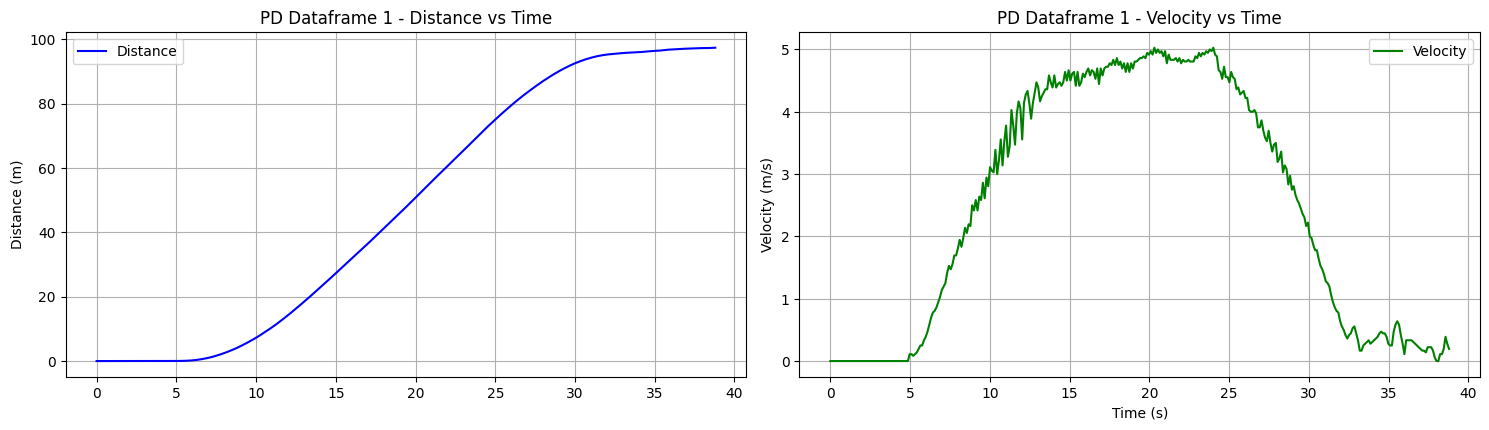


PD Dataframe 2 - Plotting Distance and Velocity:
These dataframes are autologged during testing 2


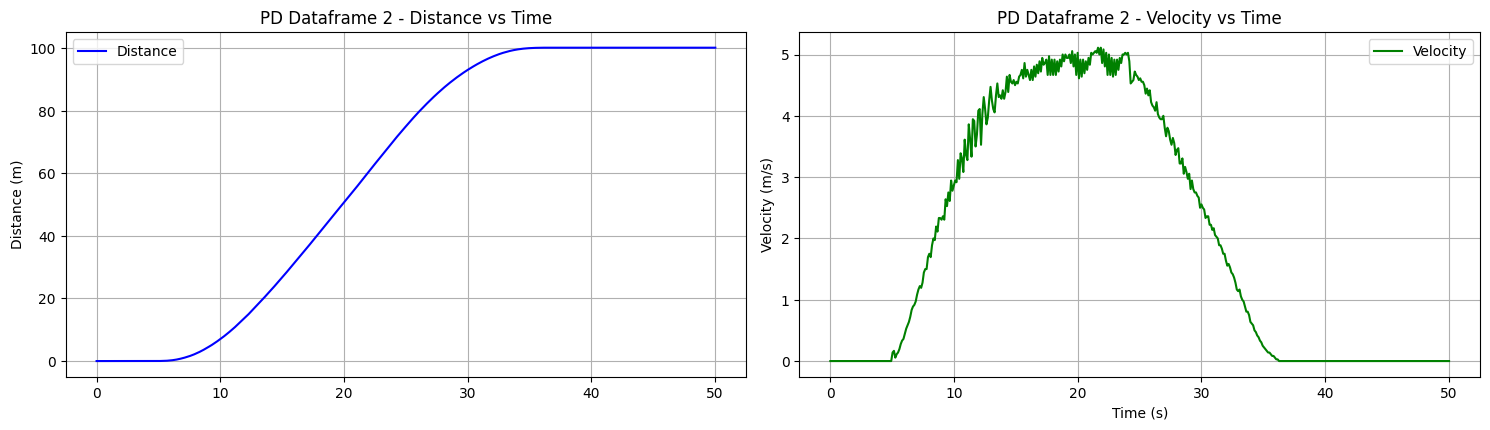


PD Dataframe 3 - Plotting Distance and Velocity:
These dataframes are autologged during testing 3


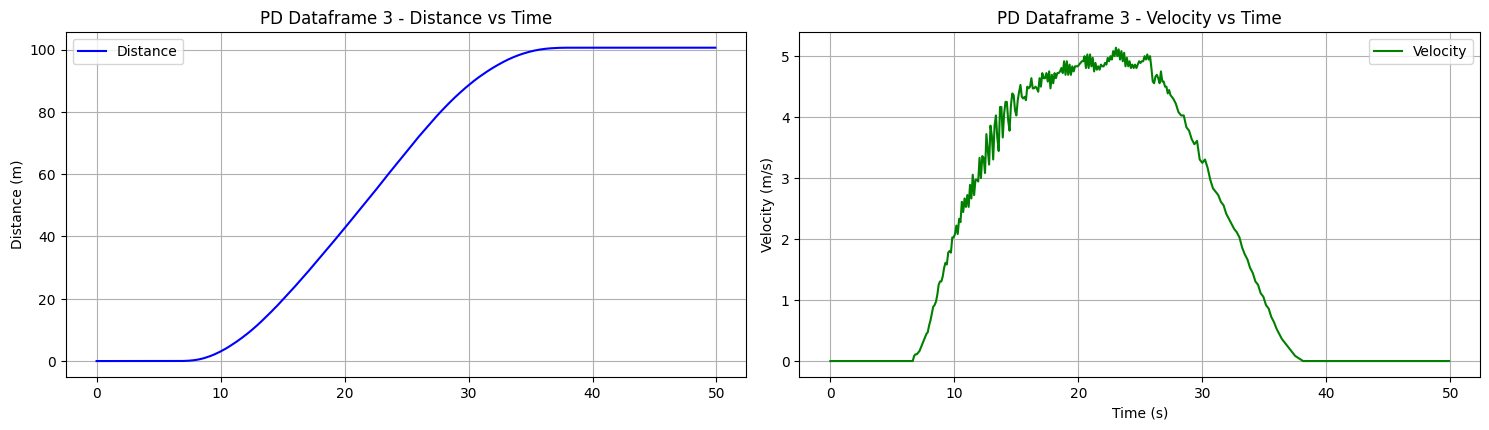


PD Dataframe 4 - Plotting Distance and Velocity:
These dataframes are autologged during testing 4


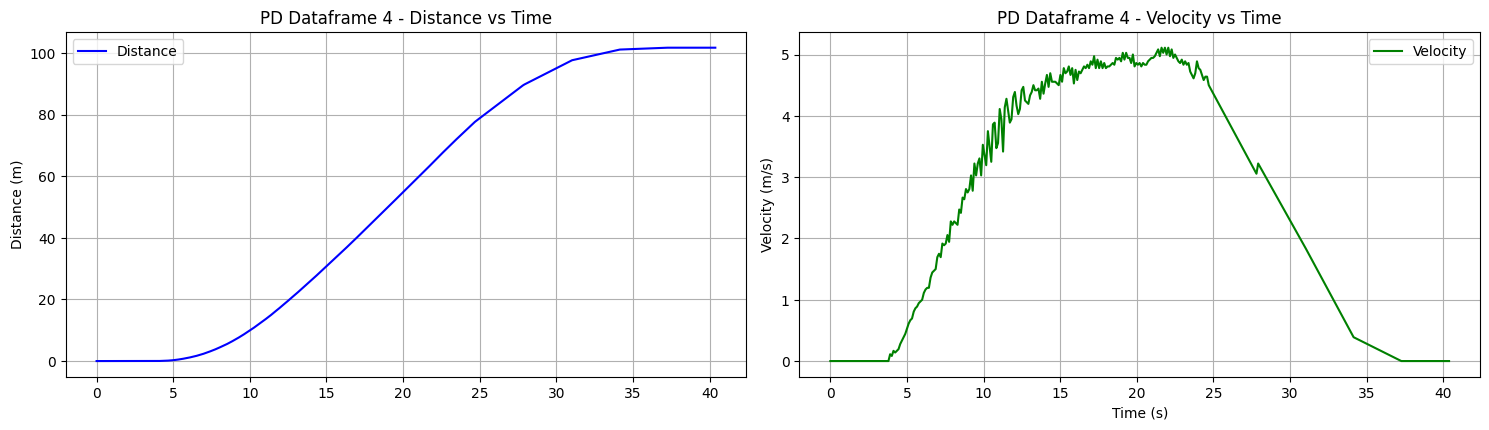


PD Dataframe 5 - Plotting Distance and Velocity:
These dataframes are autologged during testing 5


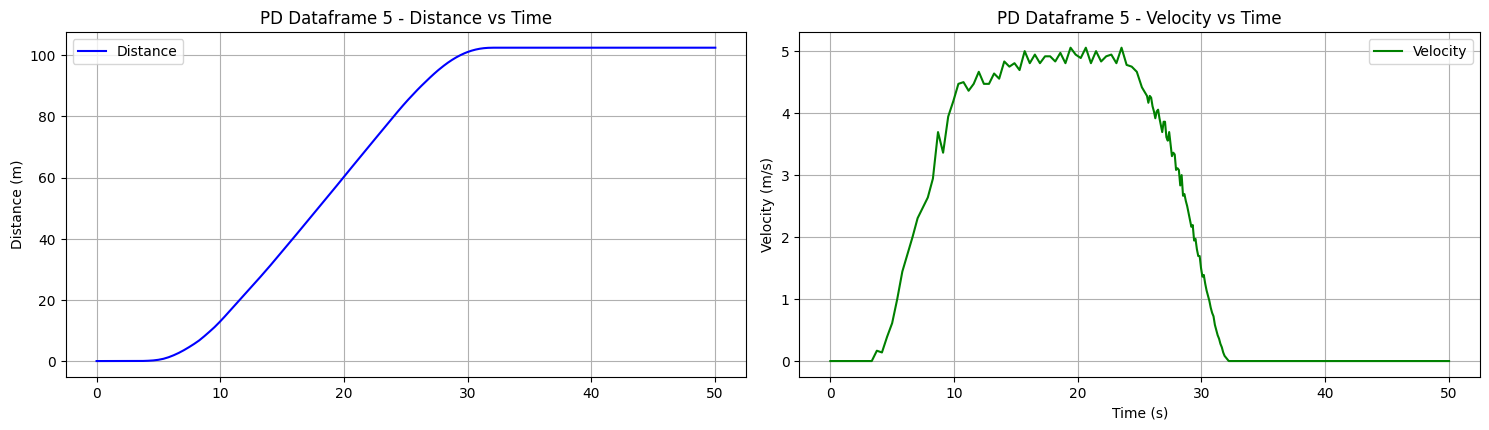


PD Dataframe 6 - Plotting Distance and Velocity:
These dataframes are autologged during testing 6


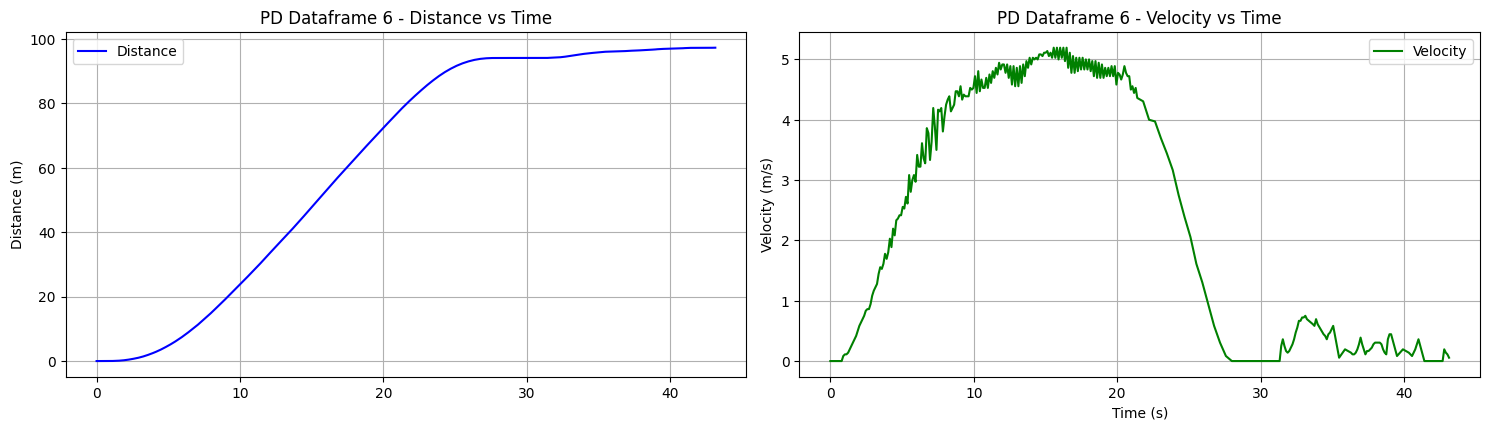


PD Dataframe 7 - Plotting Distance and Velocity:


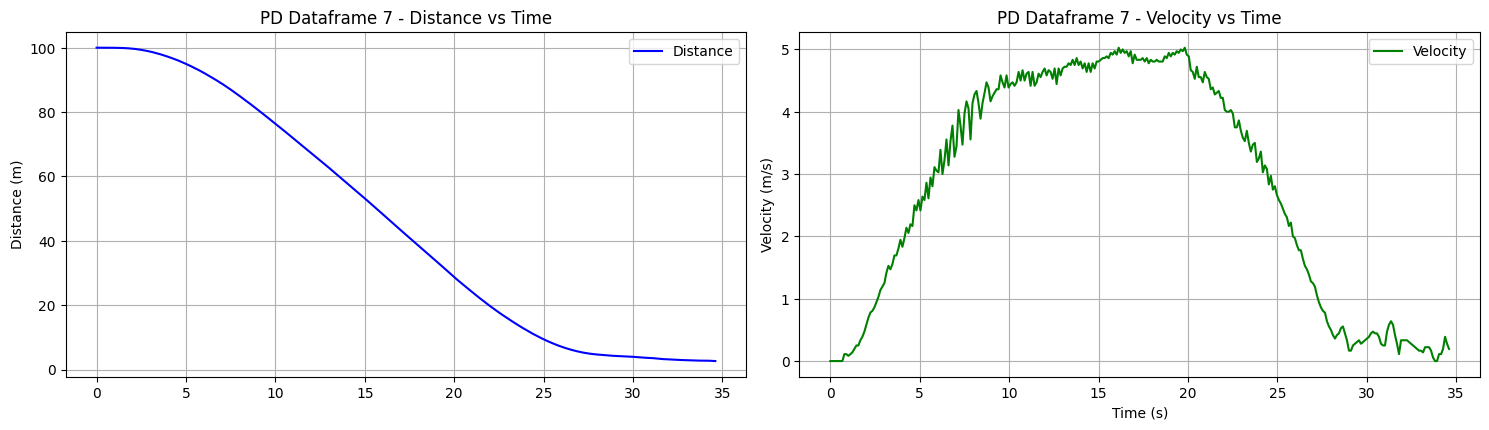


PD Dataframe 8 - Plotting Distance and Velocity:


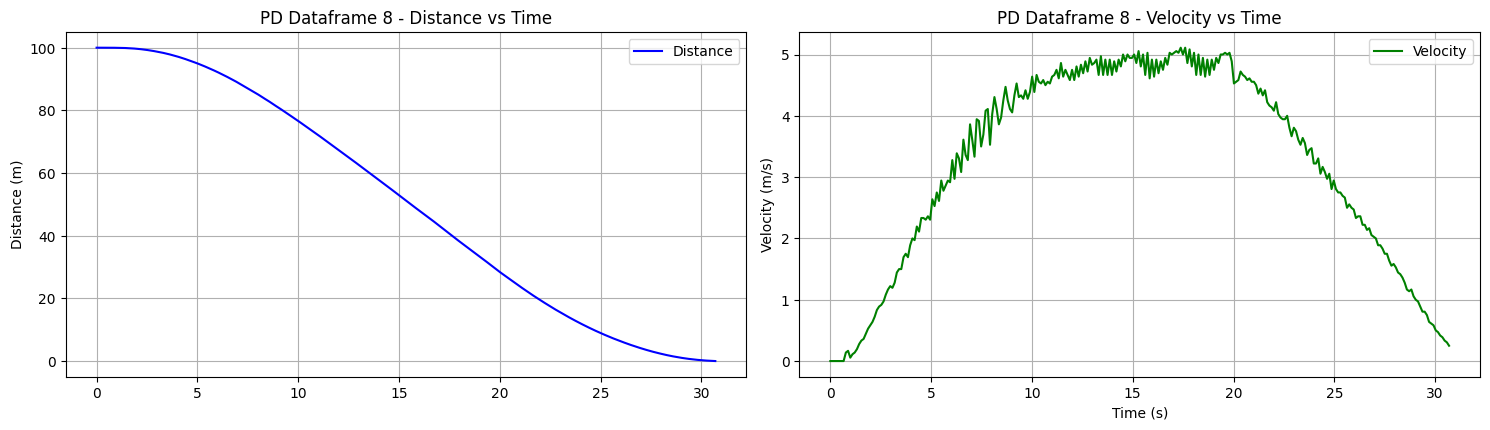


PD Dataframe 9 - Plotting Distance and Velocity:


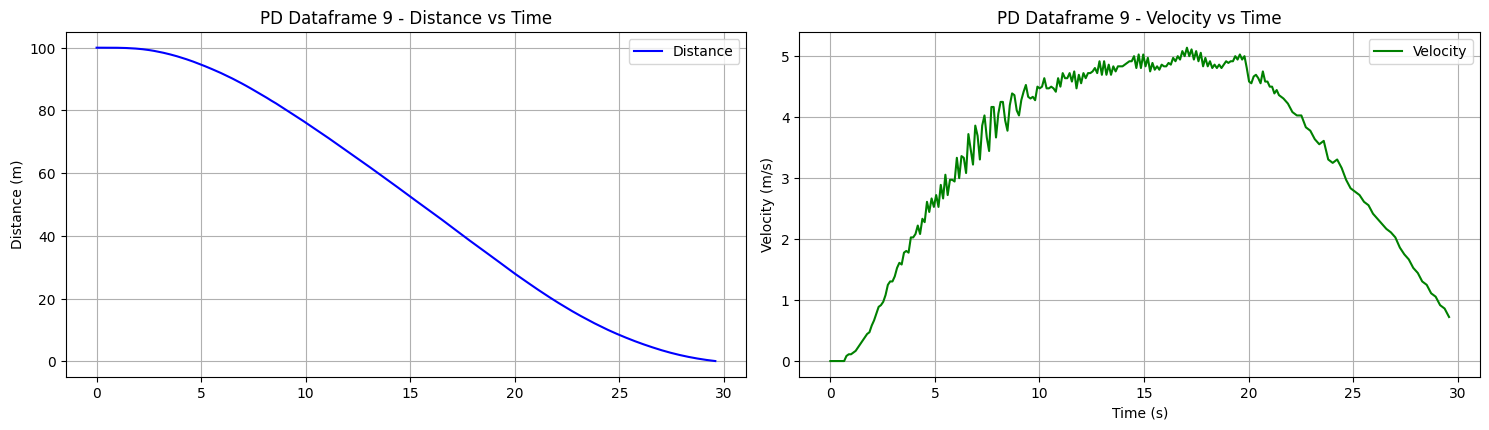


PD Dataframe 10 - Plotting Distance and Velocity:


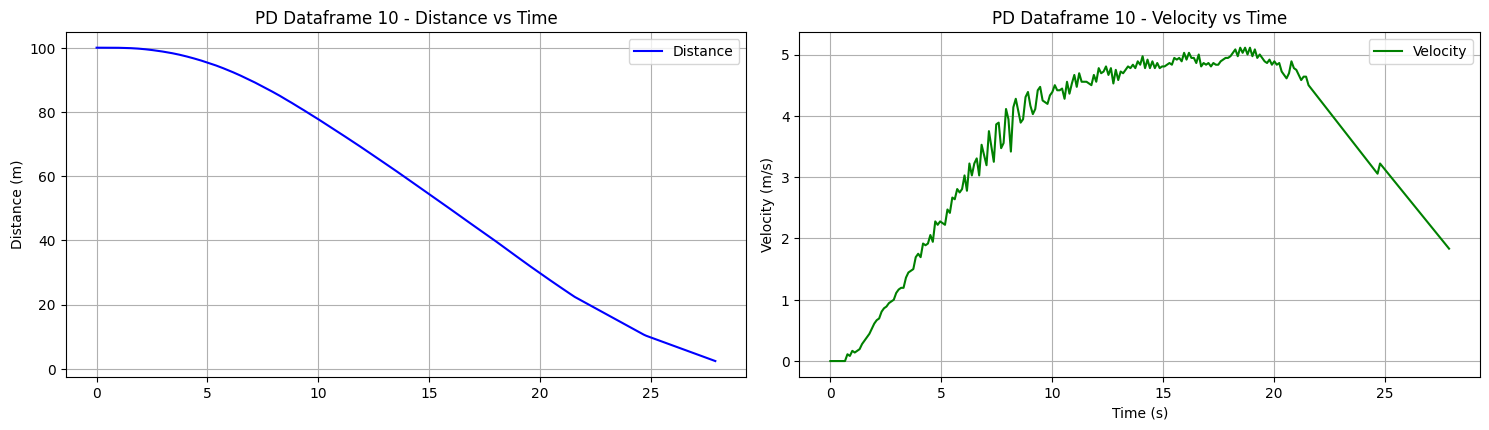


PD Dataframe 11 - Plotting Distance and Velocity:


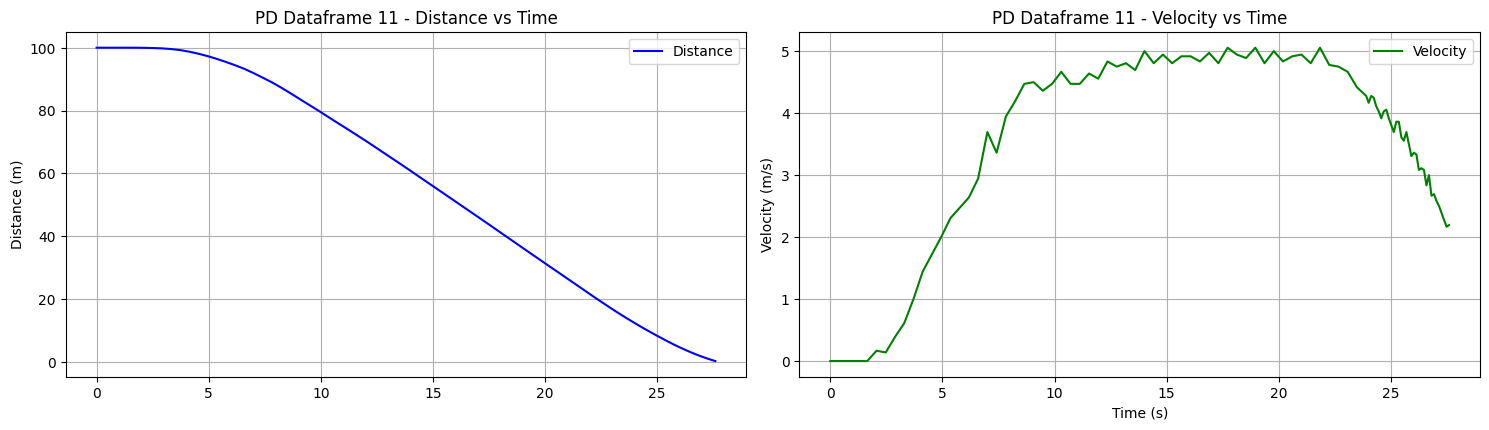


PD Dataframe 12 - Plotting Distance and Velocity:


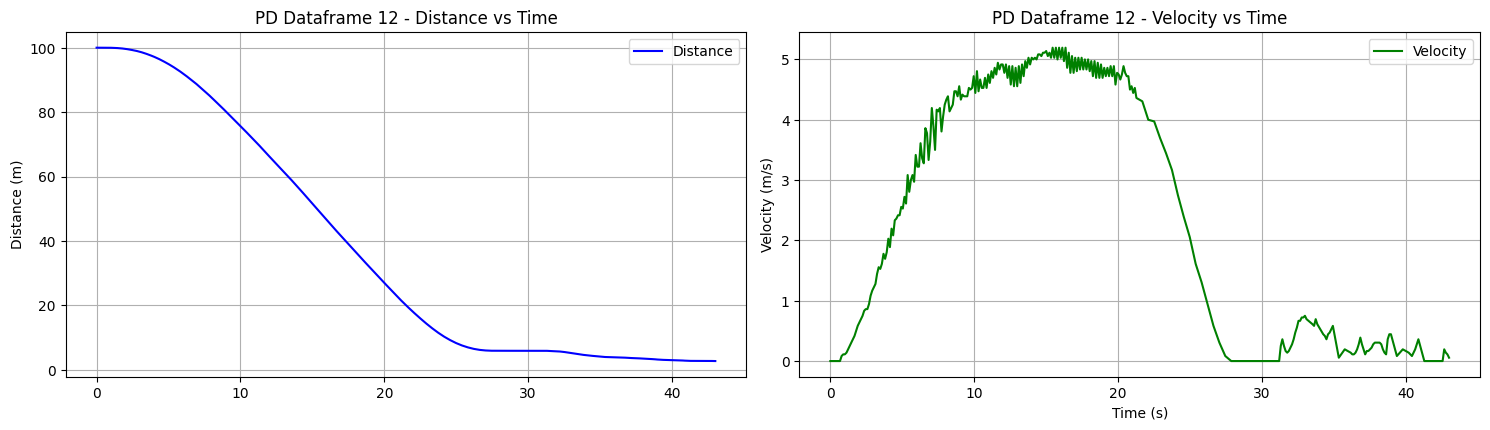


PD Dataframe 13 - Plotting Distance and Velocity:


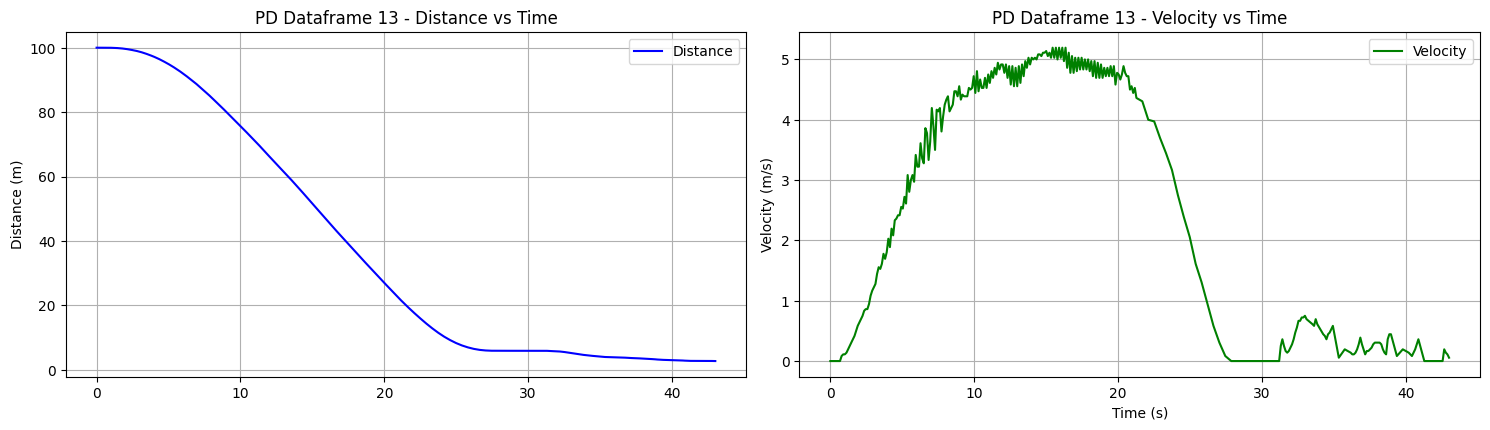

In [140]:

# Plot Distance vs Time and Velocity vs Time for each dataframe
for i, df in enumerate(pd_dataframes):
    print(f"\nPD Dataframe {i+1} - Plotting Distance and Velocity:")
    
    # Check if the required columns exist
    if "Time (s)" in df.columns and "Remaining Distance (m)" in df.columns and "Velocity (m/s)" in df.columns:
        plt.figure(figsize=(15, 8))

        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time (s)"], df["Remaining Distance (m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"PD Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time (s)"], df["Velocity (m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"PD Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    elif "Time(s)" in df.columns and "Ego_Position(m)" in df.columns and "Ego_Velocity(m/s)" in df.columns:
        plt.figure(figsize=(15, 8))
        print(f"These dataframes are autologged during testing {i+1}")
        # Distance vs Time
        plt.subplot(2, 2, 1)
        plt.plot(df["Time(s)"], df["Ego_Position(m)"], label="Distance", color="blue")
        plt.ylabel("Distance (m)")
        plt.title(f"PD Dataframe {i+1} - Distance vs Time")
        plt.grid(True)
        plt.legend()

        # Velocity vs Time
        plt.subplot(2, 2, 2)
        plt.plot(df["Time(s)"], df["Ego_Velocity(m/s)"], label="Velocity", color="green")
        plt.xlabel("Time (s)")
        plt.ylabel("Velocity (m/s)")
        plt.title(f"PD Dataframe {i+1} - Velocity vs Time")
        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()
    else:
        print(f"Dataframe {i+1} does not contain the required columns for plotting.")




